# Average Speed - LSTM


## Imports


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

## Constants


In [3]:
DATASET_PATH = "../data/v1/output_fcd.csv"

SEQUENCE_LENGTH = 30

BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

INPUT_SIZE = 1
HIDDEN_SIZE = 50
FC_SIZE = 50
OUTPUT_SIZE = 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## Load Data


In [4]:
df = pd.read_csv(DATASET_PATH, sep=";")
df

,timestep_time,vehicle_angle,vehicle_id,vehicle_lane,vehicle_pos,vehicle_slope,vehicle_speed,vehicle_type,vehicle_x,vehicle_y
0,0.0,229.42,veh0,24913519#0_2,5.10,0.0,0.00,veh_passenger,1041.41,377.58
1,1.0,229.12,veh0,24913519#0_2,7.20,0.0,2.10,veh_passenger,1039.83,376.21
2,2.0,228.82,veh0,24913519#0_2,10.91,0.0,3.71,veh_passenger,1037.04,373.76
3,3.0,228.82,veh0,24913519#0_2,16.97,0.0,6.06,veh_passenger,1032.48,369.78
4,4.0,228.82,veh0,24913519#0_2,25.29,0.0,8.32,veh_passenger,1026.22,364.30
...,...,...,...,...,...,...,...,...,...,...
37330,7199.0,271.51,veh386,1217865061#0_0,18.39,0.0,12.71,veh_passenger,244.64,113.06
37331,7199.0,237.29,veh387,-339201177#5_0,28.87,0.0,2.31,veh_passenger,643.68,380.27
37332,7199.0,265.97,veh388,4611699#0_0,55.58,0.0,13.47,veh_passenger,548.79,129.65
37333,7199.0,265.47,veh389,1149417521#2_0,1.21,0.0,14.27,veh_passenger,388.25,116.80


## Data Cleaning


In [5]:
# Drop unnecessary columns
df = df.drop(
    columns=[
        "vehicle_angle",
        "vehicle_id",
        "vehicle_lane",
        "vehicle_pos",
        "vehicle_slope",
        "vehicle_type",
        "vehicle_x",
        "vehicle_y",
    ]
)

## Feature Engineering


In [6]:
# Sort the DataFrame by timestep_time
df = df.sort_values("timestep_time")

# Create a feature for average speed
df = df.groupby("timestep_time")["vehicle_speed"].mean().reset_index()

# Rename columns for clarity
df.columns = ["timestep_time", "average_vehicle_speed"]
df

,timestep_time,average_vehicle_speed
0,0.0,0.000000
1,1.0,2.100000
2,2.0,3.710000
3,3.0,6.060000
4,4.0,8.320000
...,...,...
7195,7195.0,11.392222
7196,7196.0,11.504444
7197,7197.0,11.457778
7198,7198.0,11.282500


## Scaling


In [7]:
# Normalize the data after converting them to (n_samples, n_features) shape
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(df["average_vehicle_speed"].values.reshape(-1, 1))

## Sequence Generation


In [8]:
# Function to create sequences of data, given a sequence length
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)


X, y = create_sequences(data_normalized, SEQUENCE_LENGTH)

## Train and Validation Split


In [9]:
# Split the data into train+validation and test sets (80% train+val, 20% test)
train_val_split = int(len(X) * 0.8)
X_train_val, y_train_val = X[:train_val_split], y[:train_val_split]
X_test, y_test = X[train_val_split:], y[train_val_split:]

# Now, split the train+validation set into training and validation sets
train_split = int(len(X_train_val) * 0.8)
X_train, y_train = X_train_val[:train_split], y_train_val[:train_split]
X_val, y_val = X_train_val[train_split:], y_train_val[train_split:]

# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

# Create DataLoaders for training, validation, and test sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## LSTM Model


In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, fc_size=25, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size

        # First LSTM layer (sequences)
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        # Second LSTM layer (output at the last timestep)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, fc_size)
        self.fc2 = nn.Linear(fc_size, output_size)

    def forward(self, x):
        # (batch_size, sequence_length, input_size)
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        # (batch_size, sequence_length, hidden_size)

        # Output at the last timestep
        out = out[:, -1, :]
        # (batch_size, hidden_size)
        out = self.fc1(out)
        # (batch_size, fc_size)
        out = self.fc2(out)
        # (batch_size, output_size)
        return out

In [11]:
# Initialize model, loss function, and optimizer
model = LSTMModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, fc_size=FC_SIZE, output_size=OUTPUT_SIZE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training


In [12]:
def evaluate_model(model, val_loader, criterion, device, return_preds=False):
    model.eval()
    predictions = []
    targets = []
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            if return_preds:
                predictions.append(outputs.cpu().numpy())
                targets.append(y_batch.cpu().numpy())

    loss = running_loss / len(val_loader.dataset)

    if return_preds:
        predictions = np.concatenate(predictions, axis=0)
        targets = np.concatenate(targets, axis=0)
        return loss, predictions, targets
    else:
        return loss

In [13]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, device):
    model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation
        epoch_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(epoch_val_loss)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] - Training Loss: {epoch_train_loss:.4f} - Validation Loss: {epoch_val_loss:.4f}"
        )

    return train_losses, val_losses

In [14]:
train_losses, val_losses = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
)

Epoch [1/20] - Training Loss: 0.0485 - Validation Loss: 0.0082
Epoch [2/20] - Training Loss: 0.0088 - Validation Loss: 0.0051
Epoch [3/20] - Training Loss: 0.0062 - Validation Loss: 0.0046
Epoch [4/20] - Training Loss: 0.0046 - Validation Loss: 0.0024
Epoch [5/20] - Training Loss: 0.0029 - Validation Loss: 0.0017
Epoch [6/20] - Training Loss: 0.0023 - Validation Loss: 0.0013
Epoch [7/20] - Training Loss: 0.0020 - Validation Loss: 0.0013
Epoch [8/20] - Training Loss: 0.0020 - Validation Loss: 0.0013
Epoch [9/20] - Training Loss: 0.0020 - Validation Loss: 0.0012
Epoch [10/20] - Training Loss: 0.0021 - Validation Loss: 0.0012
Epoch [11/20] - Training Loss: 0.0019 - Validation Loss: 0.0014
Epoch [12/20] - Training Loss: 0.0018 - Validation Loss: 0.0011
Epoch [13/20] - Training Loss: 0.0018 - Validation Loss: 0.0019
Epoch [14/20] - Training Loss: 0.0018 - Validation Loss: 0.0014
Epoch [15/20] - Training Loss: 0.0019 - Validation Loss: 0.0011
Epoch [16/20] - Training Loss: 0.0018 - Validatio

## Evaluation


In [21]:
loss, predictions, targets = evaluate_model(
    model=model, val_loader=test_loader, criterion=criterion, device=DEVICE, return_preds=True
)

print(f"{criterion._get_name()}: {loss:.4f}")

MSELoss: 0.0018


## Predictions vs Targets


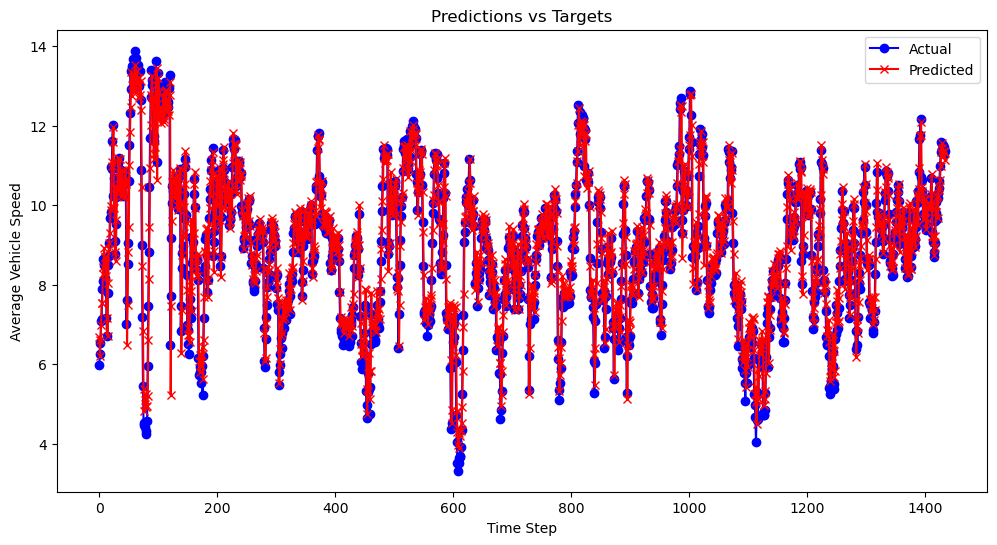

In [23]:
# Inverse transform the predictions and targets to original scale
predictions_inv = scaler.inverse_transform(predictions)
targets_inv = scaler.inverse_transform(targets)

plt.figure(figsize=(12, 6))
plt.plot(range(len(targets_inv)), targets_inv, marker="o", linestyle="-", color="b", label="Actual")
plt.plot(range(len(predictions_inv)), predictions_inv, marker="x", linestyle="-", color="r", label="Predicted")
plt.title("Predictions vs Targets")
plt.xlabel("Time Step")
plt.ylabel("Average Vehicle Speed")
plt.legend()
plt.show()